In [12]:
from src.data_processing.data_loader import MovieLensDataLoader
import pandas as pd
loader = MovieLensDataLoader()
data_dict = loader.load_data()

print("Dobijamo metapodatke iz API...")

await loader.letterboxd_data_async(max_concurrent_requests=100)

print(f"\n[Easy] Dobijeno ovoliko filmova: {len(loader.movie_data)}")

if loader.movie_data:
    print("\nPrimer prvog filma:")
    import pprint
    pprint.pprint(loader.movie_data[0])

INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:9742 films...


Dobijamo metapodatke iz API...


INFO:src.data_processing.data_loader:Successfully fetched from API: 9623 films.



[Easy] Dobijeno ovoliko filmova: 9623

Primer prvog filma:
{'cast': ['Tom Hanks',
          'Tim Allen',
          'Don Rickles',
          'Jim Varney',
          'Wallace Shawn'],
 'director': 'John Lasseter',
 'main_actor': 'Tom Hanks',
 'rating': 8.0,
 'runtime': 81,
 'title': 'Toy Story',
 'year': '1995'}


In [13]:
import pandas as pd
movie_metadata = loader.movie_data
movie_metadata
df = pd.DataFrame(movie_metadata)

def cleaner(x):
    if isinstance(x, list):
        return [str.lower(i).replace(' ', '-') for i in x]
    elif isinstance(x, str):
        return str.lower(x).replace(' ', '-')
    return ""
df.head()
df['title_clean'] = df['title'].apply(cleaner)
df['main_actor_clean'] = df['main_actor'].apply(cleaner)
df['director_clean'] = df['director'].apply(cleaner)
df["rating"] = df["rating"].astype(float) / 2.0
df["cast_clean"] = df["cast"].apply(cleaner).apply(lambda x: [i for i in x if i])
a = loader.preprocess_movies()
df['genres_text'] = a.apply(lambda row: ' '.join([col.lower().replace(" ", "") for col in a.columns if row[col]]), 
    axis=1)
#df["genres_clean"] = df["genres"].apply(cleaner).apply(lambda x: [i for i in x if i])

df.head(10)


,title,year,cast,main_actor,director,rating,runtime,title_clean,main_actor_clean,director_clean,cast_clean,genres_text
0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,4.0000,81,toy-story,tom-hanks,john-lasseter,"[tom-hanks, tim-allen, don-rickles, jim-varney...",genre_adventure genre_animation genre_children...
1,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,3.6235,104,jumanji,robin-williams,joe-johnston,"[robin-williams, kirsten-dunst, bradley-pierce...",genre_adventure genre_children genre_fantasy
2,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,3.2390,101,grumpier-old-men,walter-matthau,howard-deutch,"[walter-matthau, jack-lemmon, ann-margret, sop...",genre_comedy genre_romance
3,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,3.1215,127,waiting-to-exhale,whitney-houston,forest-whitaker,"[whitney-houston, angela-bassett, loretta-devi...",genre_comedy genre_drama genre_romance
4,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,3.1370,106,father-of-the-bride-part-ii,steve-martin,charles-shyer,"[steve-martin, diane-keaton, martin-short, kim...",genre_comedy
5,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,3.9685,170,heat,al-pacino,michael-mann,"[al-pacino, robert-de-niro, val-kilmer, jon-vo...",genre_action genre_crime genre_thriller
6,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,3.1060,127,sabrina,harrison-ford,sydney-pollack,"[harrison-ford, julia-ormond, greg-kinnear, na...",genre_comedy genre_romance
7,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,2.6500,97,tom-and-huck,jonathan-taylor-thomas,peter-hewitt,"[jonathan-taylor-thomas, brad-renfro, eric-sch...",genre_adventure genre_children
8,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,3.0170,111,sudden-death,jean-claude-van-damme,peter-hyams,"[jean-claude-van-damme, powers-boothe, raymond...",genre_action
9,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,3.4510,130,goldeneye,pierce-brosnan,martin-campbell,"[pierce-brosnan, sean-bean, izabella-scorupco,...",genre_action genre_adventure genre_thriller


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

median_runtime = df["runtime"].replace(0, np.nan).median()
df["runtime_filled"] = df["runtime"].replace({0: median_runtime, np.nan: median_runtime})

df["runtime_log"] = np.log1p(df["runtime_filled"])

scaler = MinMaxScaler()
df["runtime_scaled"] = scaler.fit_transform(df[["runtime_log"]])
df[["runtime", "runtime_filled", "runtime_log", "runtime_scaled"]].sort_values("runtime_scaled").head(50)

,runtime,runtime_filled,runtime_log,runtime_scaled
9611,2,2,1.098612,0.000000
6068,2,2,1.098612,0.000000
7598,3,3,1.386294,0.054575
9317,3,3,1.386294,0.054575
9287,4,4,1.609438,0.096907
7871,4,4,1.609438,0.096907
7881,4,4,1.609438,0.096907
9496,4,4,1.609438,0.096907
2561,5,5,1.791759,0.131495
8478,5,5,1.791759,0.131495


In [16]:
df['main_actor_rating'] = df.groupby('main_actor_clean')['rating'].transform('mean')
median_rating_actor = df["main_actor_rating"].replace(0, np.nan).median()
df["main_actor_rating_filled"] = df["main_actor_rating"].replace({0: median_rating_actor, np.nan: median_rating_actor})

df["main_actor_rating_log"] = np.log1p(df["main_actor_rating_filled"])

scaler = MinMaxScaler()
df["main_actor_rating_scaled"] = scaler.fit_transform(df[["main_actor_rating_log"]])
df.head(10)

,title,year,cast,main_actor,director,rating,runtime,title_clean,main_actor_clean,director_clean,cast_clean,genres_text,runtime_filled,runtime_log,runtime_scaled,main_actor_rating,main_actor_rating_filled,main_actor_rating_log,main_actor_rating_scaled
0,Toy Story,1995,"[Tom Hanks, Tim Allen, Don Rickles, Jim Varney...",Tom Hanks,John Lasseter,4.0000,81,toy-story,tom-hanks,john-lasseter,"[tom-hanks, tim-allen, don-rickles, jim-varney...",genre_adventure genre_animation genre_children...,81,4.406719,0.627571,3.474757,3.474757,1.498452,0.835097
1,Jumanji,1995,"[Robin Williams, Kirsten Dunst, Bradley Pierce...",Robin Williams,Joe Johnston,3.6235,104,jumanji,robin-williams,joe-johnston,"[robin-williams, kirsten-dunst, bradley-pierce...",genre_adventure genre_children genre_fantasy,104,4.653960,0.674474,3.214224,3.214224,1.438466,0.774414
2,Grumpier Old Men,1995,"[Walter Matthau, Jack Lemmon, Ann-Margret, Sop...",Walter Matthau,Howard Deutch,3.2390,101,grumpier-old-men,walter-matthau,howard-deutch,"[walter-matthau, jack-lemmon, ann-margret, sop...",genre_comedy genre_romance,101,4.624973,0.668975,3.361063,3.361063,1.472716,0.809062
3,Waiting to Exhale,1995,"[Whitney Houston, Angela Bassett, Loretta Devi...",Whitney Houston,Forest Whitaker,3.1215,127,waiting-to-exhale,whitney-houston,forest-whitaker,"[whitney-houston, angela-bassett, loretta-devi...",genre_comedy genre_drama genre_romance,127,4.852030,0.712049,3.121500,3.121500,1.416217,0.751907
4,Father of the Bride Part II,1995,"[Steve Martin, Diane Keaton, Martin Short, Kim...",Steve Martin,Charles Shyer,3.1370,106,father-of-the-bride-part-ii,steve-martin,charles-shyer,"[steve-martin, diane-keaton, martin-short, kim...",genre_comedy,106,4.672829,0.678054,3.137433,3.137433,1.420076,0.755811
5,Heat,1995,"[Al Pacino, Robert De Niro, Val Kilmer, Jon Vo...",Al Pacino,Michael Mann,3.9685,170,heat,al-pacino,michael-mann,"[al-pacino, robert-de-niro, val-kilmer, jon-vo...",genre_action genre_crime genre_thriller,170,5.141664,0.766995,3.521640,3.521640,1.508875,0.845641
6,Sabrina,1995,"[Harrison Ford, Julia Ormond, Greg Kinnear, Na...",Harrison Ford,Sydney Pollack,3.1060,127,sabrina,harrison-ford,sydney-pollack,"[harrison-ford, julia-ormond, greg-kinnear, na...",genre_comedy genre_romance,127,4.852030,0.712049,3.313523,3.313523,1.461755,0.797974
7,Tom and Huck,1995,"[Jonathan Taylor Thomas, Brad Renfro, Eric Sch...",Jonathan Taylor Thomas,Peter Hewitt,2.6500,97,tom-and-huck,jonathan-taylor-thomas,peter-hewitt,"[jonathan-taylor-thomas, brad-renfro, eric-sch...",genre_adventure genre_children,97,4.584967,0.661386,2.861000,2.861000,1.350926,0.685858
8,Sudden Death,1995,"[Jean-Claude Van Damme, Powers Boothe, Raymond...",Jean-Claude Van Damme,Peter Hyams,3.0170,111,sudden-death,jean-claude-van-damme,peter-hyams,"[jean-claude-van-damme, powers-boothe, raymond...",genre_action,111,4.718499,0.686718,2.950000,2.950000,1.373716,0.708912
9,GoldenEye,1995,"[Pierce Brosnan, Sean Bean, Izabella Scorupco,...",Pierce Brosnan,Martin Campbell,3.4510,130,goldeneye,pierce-brosnan,martin-campbell,"[pierce-brosnan, sean-bean, izabella-scorupco,...",genre_action genre_adventure genre_thriller,130,4.875197,0.716444,3.083115,3.083115,1.406860,0.742442


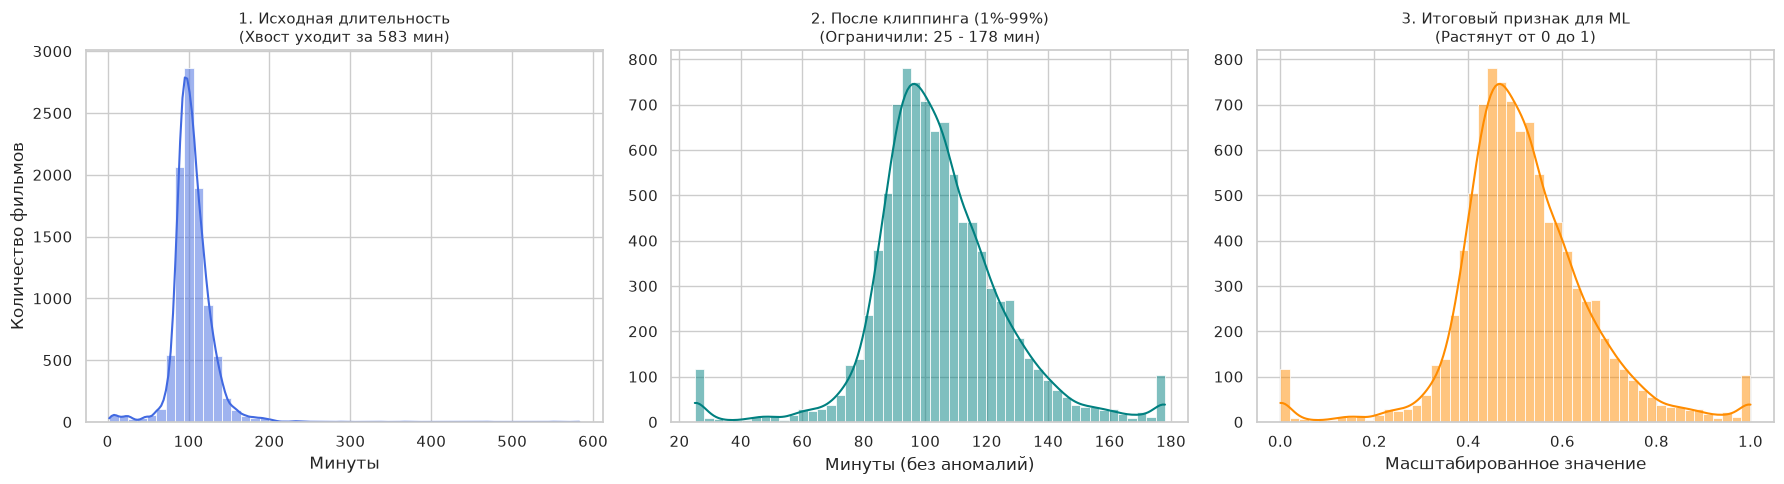

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# --- 1. Подготовка данных (Заполнение пропусков) ---
median_runtime = df["runtime"].replace(0, np.nan).median()
df["runtime_filled"] = df["runtime"].replace(
    {0: median_runtime, np.nan: median_runtime}
)

# --- 2. Клиппинг (Срезаем топ-1% экстремально длинных и коротких фильмов) ---
lower_bound = df["runtime_filled"].quantile(0.01)  # Отрежет скрытый мусор
upper_bound = df["runtime_filled"].quantile(0.99)  # Отрежет фильмы длиннее ~3.5 часов

df["runtime_clipped"] = df["runtime_filled"].clip(lower_bound, upper_bound)

# --- 3. Масштабирование в диапазон [0, 1] ---
scaler = MinMaxScaler()
df["runtime_scaled"] = scaler.fit_transform(df[["runtime_clipped"]])

# --- 4. Отрисовка новых графиков в Jupyter ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Исходные данные с хвостами
sns.histplot(
    df["runtime_filled"], bins=50, kde=True, ax=axes[0], color="royalblue"
)
axes[0].set_title(
    f"1. Исходная длительность\n(Хвост уходит за {int(df['runtime_filled'].max())} мин)",
    fontsize=11,
)
axes[0].set_xlabel("Минуты")
axes[0].set_ylabel("Количество фильмов")

# График 2: Данные после клиппинга
sns.histplot(
    df["runtime_clipped"], bins=50, kde=True, ax=axes[1], color="teal"
)
axes[1].set_title(
    f"2. После клиппинга (1%-99%)\n(Ограничили: {int(lower_bound)} - {int(upper_bound)} мин)",
    fontsize=11,
)
axes[1].set_xlabel("Минуты (без аномалий)")
axes[1].set_ylabel("")

# График 3: Финальный признак для Content-Based
sns.histplot(
    df["runtime_scaled"], bins=50, kde=True, ax=axes[2], color="darkorange"
)
axes[2].set_title(
    "3. Итоговый признак для ML\n(Растянут от 0 до 1)", fontsize=11
)
axes[2].set_xlabel("Масштабированное значение")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


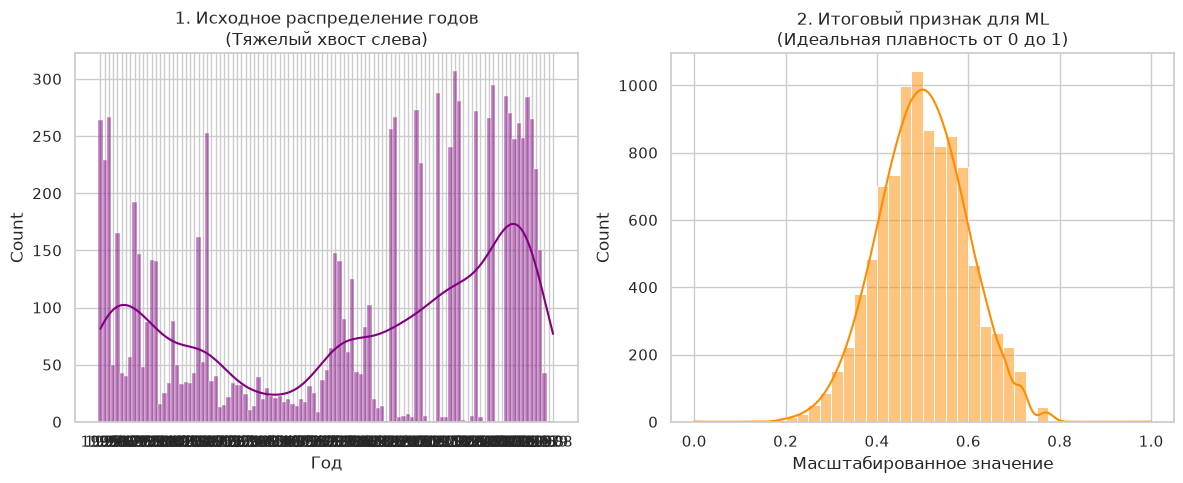

0       0.472358
1       0.472358
2       0.472358
3       0.472358
4       0.472358
          ...   
9616    0.715510
9617    0.715510
9618    0.715510
9619    0.769910
9620    0.450757
Name: year_scaled, Length: 9621, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer

# 1. Заполняем пропуски медианой (если они есть)
median_year = df["year"].astype(int).median()
df["year_filled"] = df["year"].fillna(median_year)

# 2. Применяем QuantileTransformer с нормальным распределением
# Обучаем трансформер
qt_year = QuantileTransformer(
    output_distribution="normal", n_quantiles=1000, random_state=42
)
year_transformed = qt_year.fit_transform(df[["year_filled"]])

# 3. Так как 'normal' выдает значения в пределах [-3, 3], сжимаем их в [0, 1] через MinMaxScaler
scaler_year = MinMaxScaler()
df["year_scaled"] = scaler_year.fit_transform(year_transformed)

# --- Визуализация ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["year_filled"], bins=40, kde=True, ax=axes[0], color="purple")
axes[0].set_title("1. Исходное распределение годов\n(Тяжелый хвост слева)")
axes[0].set_xlabel("Год")

sns.histplot(df["year_scaled"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("2. Итоговый признак для ML\n(Идеальная плавность от 0 до 1)")
axes[1].set_xlabel("Масштабированное значение")

plt.tight_layout()
plt.show()